In [1]:
# Import Required Libraries
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace, entropy
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)


Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


GHZ state circuit:
     ┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
c: 3/═══════════════
                    

GHZ statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))

Measurement counts: {'111': 532, '000': 492}


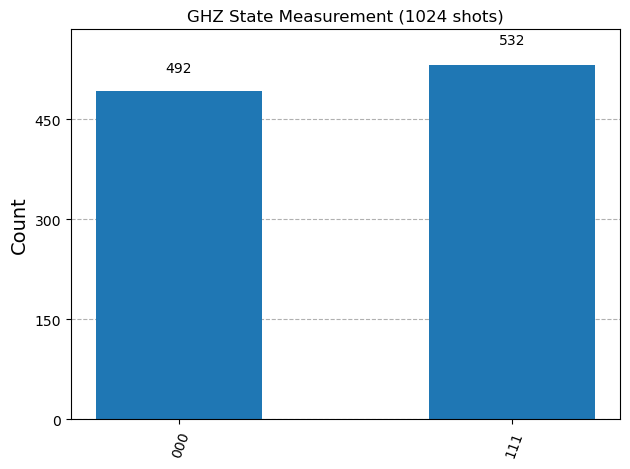

In [2]:
# Three-qubit GHZ state = (|000> + |111>) / sqrt(2)

ghz = QuantumCircuit(3, 3)
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(0, 2)

print("GHZ state circuit:")
print(ghz)

ghz_state = Statevector.from_instruction(ghz)
print("\nGHZ statevector:")
print(ghz_state)

ghz_measure = ghz.copy()
ghz_measure.measure([0, 1, 2], [0, 1, 2])

job = simulator.run(ghz_measure, shots=1024)
counts = job.result().get_counts()

print("\nMeasurement counts:", counts)
plot_histogram(counts, title="GHZ State Measurement (1024 shots)")
